
# Telecom Customer Churn & Retention Analytics

## Aim:

The objective is to analyze customer data using numerical and categorical features to identify churn patterns, understand key factors influencing customer retention, and generate actionable business insights.

## Dataset Overview:

The [dataset](https://github.com/ARZO0876543/Customer-Churn-Retention-Analytics/blob/main/dataset/Telco-Customer-Churn-kaggle.csv) encompasses diverse attributes providing valuable insights into customer details and interactions. Customer-specific details include a unique identifier (**customerID**), gender information, and a binary indicator denoting whether the customer is a senior citizen (**SeniorCitizen**).

Additional attributes capture relational aspects, such as whether the customer has a partner (**Partner**) and dependents (**Dependents**). The **tenure** attribute signifies the duration, in months, for which the customer has been associated with the company.

Communication services are represented by attributes like **PhoneService** and **MultipleLines**, indicating the presence of phone service and whether the customer has multiple lines. Internet-related features encompass the **InternetService** provider, online security (**OnlineSecurity**), online backup (**OnlineBackup**), device protection (**DeviceProtection**), and tech support (**TechSupport**).

Entertainment services are reflected in attributes like streaming TV (**StreamingTV**) and streaming movies (**StreamingMovies**). The **Contract** attribute reveals the duration of the customer's contract, with options such as month-to-month, one year, and two years.

Billing preferences are outlined through the **PaperlessBilling** attribute, indicating whether the customer opts for paperless billing. The **PaymentMethod** attribute specifies how customers choose to pay, with options like electronic check, mailed check, bank transfer (automatic), and credit card (automatic).

Financial details include the **MonthlyCharges** the customer incurs on a monthly basis and the overall **TotalCharges** accumulated.

Lastly, the critical attribute of **Churn** denotes whether the customer has churned, serving as a crucial factor in understanding customer retention dynamics

### Importing Essential Libraries

To proceed with the analysis, we need to import the essential libraries. These libraries provide the necessary tools and functions to manipulate, visualize, and analyze the dataset effectively. The following libraries will be imported for this purpose.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Telco-Customer-Churn-kaggle.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preprocessing

In [3]:
#overview of data columns 
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
#TotalCharges to float datatype
#coverting senior citizen from(0,1) -> (no,yes)

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce')
data['SeniorCitizen'] = pd.to_numeric(data['SeniorCitizen'],errors='coerce')
data['SeniorCitizen'] = data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})


In [5]:

data['SeniorCitizen'].head()

0    No
1    No
2    No
3    No
4    No
Name: SeniorCitizen, dtype: str

In [6]:
#checking for null values 
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
#info about numerical data columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.00,2283.30,2266.77,18.80,401.45,1397.47,3794.74,8684.80


In [8]:
data= data.drop(columns=['customerID'])



In [9]:
data['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
data.index[data['TotalCharges'].isnull()].tolist()

[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]

In [11]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

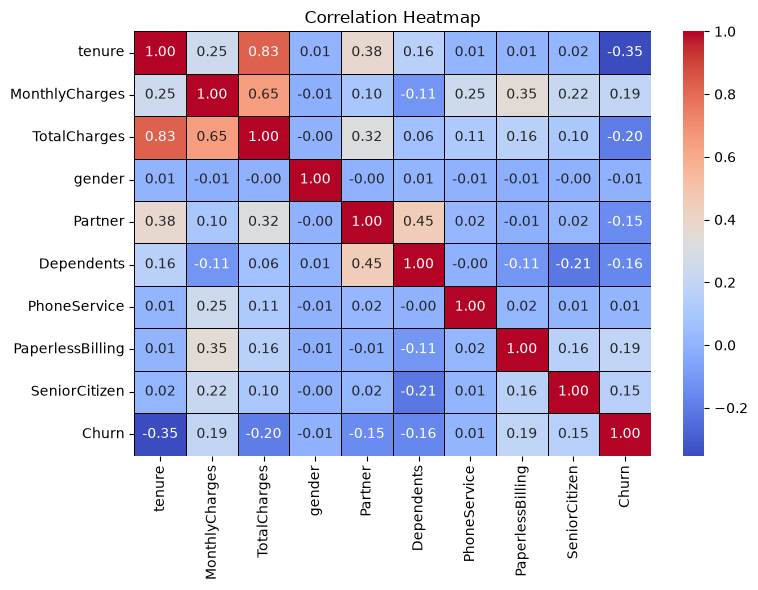

In [12]:
#correlation between numercial /binary column and churn

# Select numerical features
numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Select binary categorical features
binary_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'SeniorCitizen',
    'Churn'
]

# Create correlation dataframe
corr_data = data[numerical_features + binary_features].copy()

# Convert binary categorical columns into 0/1
corr_data['gender'] = corr_data['gender'].map({'Female': 0, 'Male': 1})
corr_data['Partner'] = corr_data['Partner'].map({'No': 0, 'Yes': 1})
corr_data['Dependents'] = corr_data['Dependents'].map({'No': 0, 'Yes': 1})
corr_data['PhoneService'] = corr_data['PhoneService'].map({'No': 0, 'Yes': 1})
corr_data['SeniorCitizen'] = corr_data['SeniorCitizen'].map({'No': 0, 'Yes': 1})
corr_data['PaperlessBilling'] = corr_data['PaperlessBilling'].map({'No': 0, 'Yes': 1})
corr_data['Churn'] = corr_data['Churn'].map({'No': 0, 'Yes': 1})

# Correlation
corr = corr_data.corr()

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.4,
    linecolor='black',
    fmt='.2f',
    cbar=True
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



### Key Observations from the Correlation Heatmap

- **Tenure:** Strongest negative correlation with Churn (**-0.35**), suggesting longer-tenure customers are less likely to churn.
- **TotalCharges:** Weak negative correlation (**-0.20**), indicating customers with higher accumulated charges tend to churn slightly less.
- **SeniorCitizen:** Weak positive correlation (**0.15**), suggesting a slightly higher tendency to churn.
- **Partner & Dependents:** Weak negative correlations (**-0.15** and **-0.16**), indicating slightly lower churn among customers with partners or dependents.
- **Gender & PhoneService:** Almost zero correlation (**-0.01** and **0.01**), indicating little to no linear relationship with churn.

# Exploratory Data Analysis (EDA)

In [13]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [14]:
#Dividing features into Numerical and Categorical :

col = list(data.columns)

categorical_features = data.select_dtypes(include='object').columns.tolist()
numerical_features = data.select_dtypes(include='number').columns.tolist()

print("Categorical Features:")
for feature in categorical_features:
    print(f"- {feature}")

print("\nNumerical Features:")
for feature in numerical_features:
    print(f"- {feature}")



Categorical Features:
- gender
- SeniorCitizen
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- Churn

Numerical Features:
- tenure
- MonthlyCharges
- TotalCharges


## Churn Variable Visualization

Understanding the distribution of the target variable, "Churn," is crucial for gaining insights into customer behavior. In this visualization:

- **Churn Distribution:** We explore the distribution of churned and not-churned customers to gauge the imbalance in the dataset.

- **Visual Representation:** Utilizing graphs or charts to present a clear and concise overview of the proportion of customers who churned and those who did not.

- **Insights:** Analyzing patterns in churn distribution can reveal potential challenges and opportunities in addressing customer retention.

This visualization serves as a foundational step in comprehending the dataset's target variable, setting the stage for more in-depth analyses and modeling

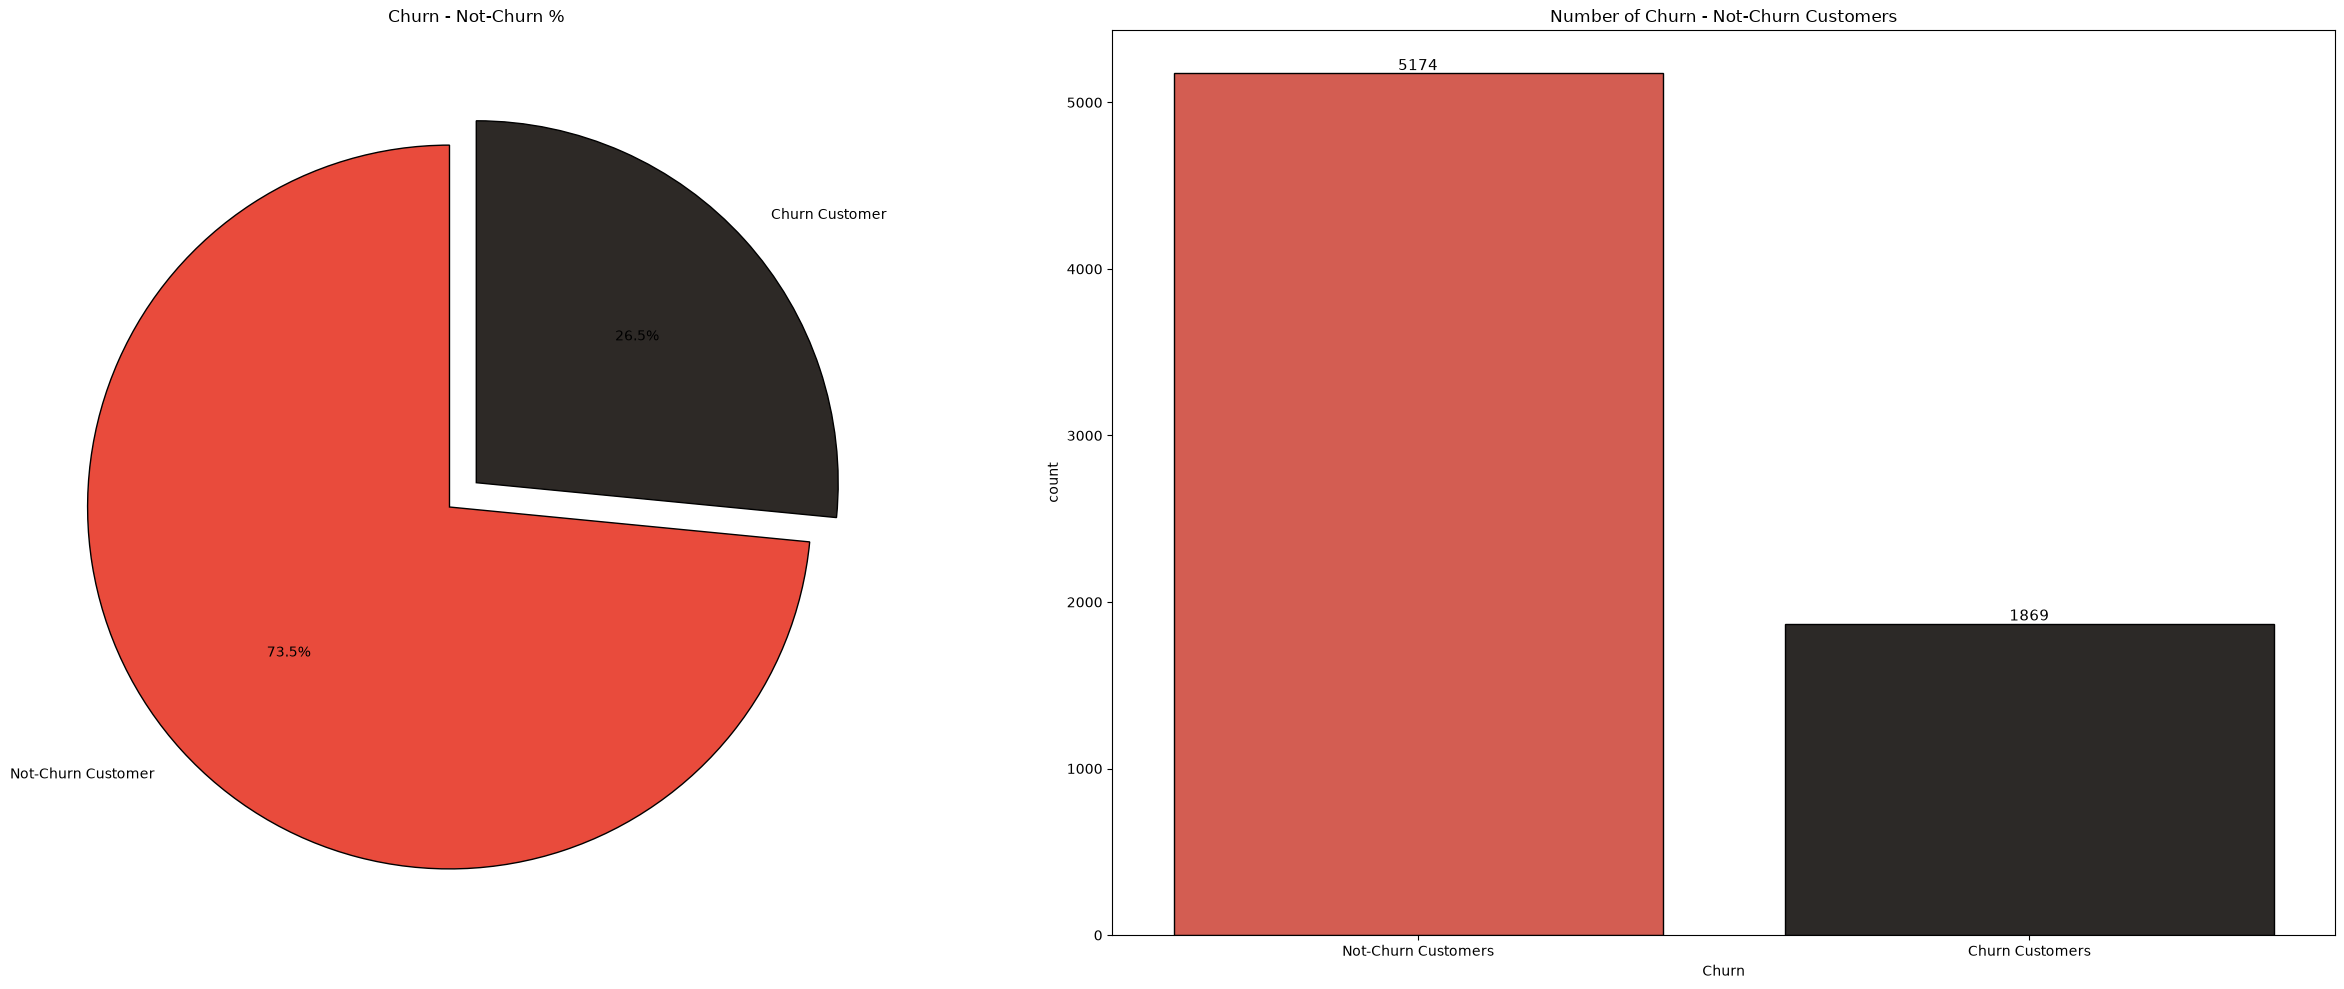

In [15]:
colors = ['#2E86AB', '#E63946']  # teal blue = Not-Churn, coral red = Churn

# Churn counts from original data
l = list(data['Churn'].value_counts())

circle = [
    l[0] / sum(l) * 100,
    l[1] / sum(l) * 100
]

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 10))

# ---------------- Pie Chart ----------------
axes[0].pie(
    circle,
    labels=['Not-Churn Customer', 'Churn Customer'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0),
    colors=colors,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1,
        'antialiased': True
    }
)

axes[0].set_title('Churn - Not-Churn %')


# ---------------- Count Plot ----------------
ax = sns.countplot(
    x='Churn',
    data=data,
    palette=colors,
    edgecolor='black'
)

for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 20,
        int(rect.get_height()),
        horizontalalignment='center',
        fontsize=11
    )

ax.set_xticklabels(['Not-Churn Customers', 'Churn Customers'])
ax.set_title('Number of Churn - Not-Churn Customers')

plt.tight_layout()
plt.show()

The dataset exhibits an imbalanced distribution, with a ratio of approximately 3:1 for Not-Churn to Churn customers. 

Visualizations will vividly illustrate this disparity, emphasizing the challenge posed by the skewed distribution in the dataset. Addressing this class imbalance will be a crucial consideration in subsequent modeling steps to ensure a more accurate and meaningful predictive outcome.

## Categorical Features and Their Impact on the Target Variable (Churn)

For visualization purposes, we will exclude the target variable, "Churn," from the list of categorical features. This allows for a focused examination of how other categorical attributes influence the likelihood of customer churn.

In [16]:
categorical_features.remove('Churn')

To manage the abundance of categorical features in the dataset, we classify them into three groups based on their values or column names. This categorization aids in organizing and analyzing the features more effectively, allowing for a structured exploration of their impact on the target variable.

In [17]:
l1 = ['gender','SeniorCitizen','Partner','Dependents'] # Customer Information
l2 = ['PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies',
      'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport'] # Services Signed Up for!
l3 = ['Contract','PaperlessBilling','PaymentMethod'] # Payment Information

## Group 1: Customer Information

This category encompasses attributes related to customer demographics and characteristics:

- **Gender**
- **SeniorCitizen**
- **Partner**
- **Dependents**

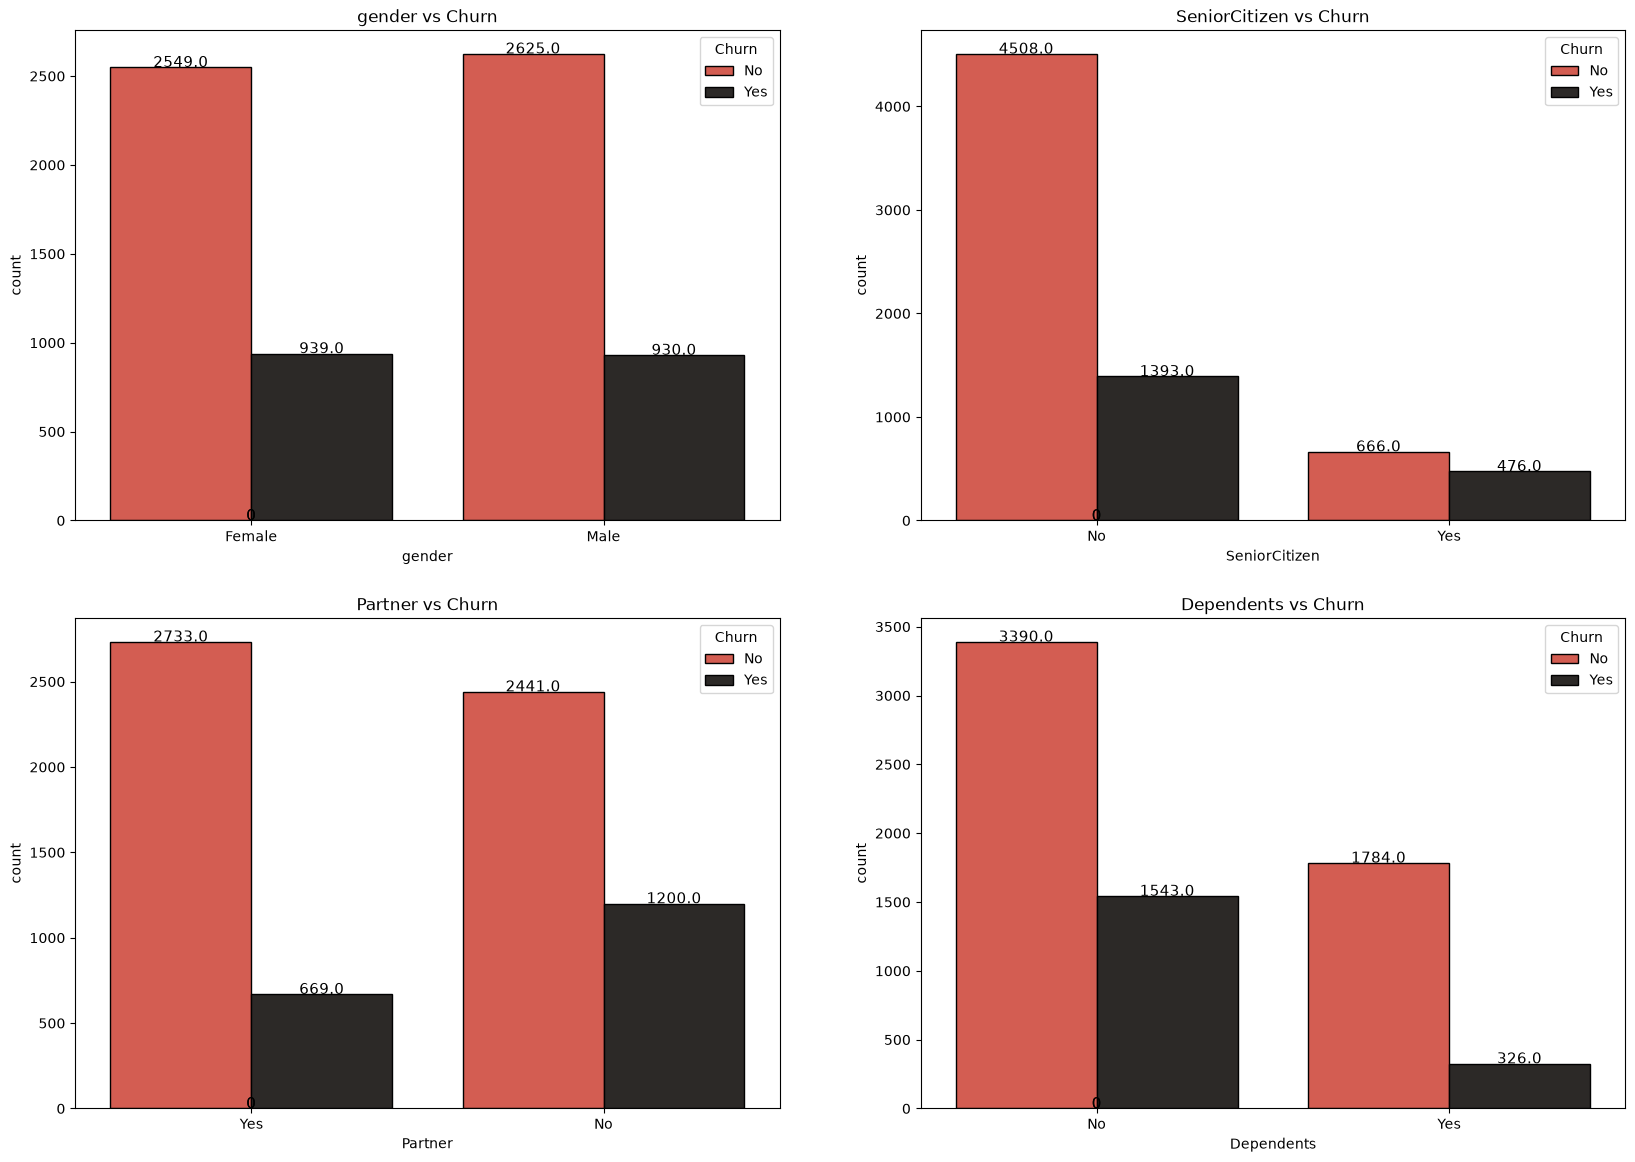

In [18]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l1)):
    plt.subplot(2,2,i+1)
    ax = sns.countplot(x=l1[i],data = data,hue = "Churn",palette = colors,edgecolor = 'black')
    for rect in ax.patches:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
    title = l1[i] + ' vs Churn'
    plt.title(title);

- **Gender Churn Analysis:**
  Customer churn rates are comparable between male and female customers, indicating similarity in churn behavior across genders.

- **SeniorCitizen Analysis:**
  The number of SeniorCitizen customers is relatively low. However, among SeniorCitizens, approximately 40% experienced churn, accounting for 476 out of 1142 Senior Citizen customers.

- **Partner Status Impact:**
  Customers residing with a partner exhibit lower churn rates compared to those without a partner.

- **Dependents Influence:**
  Churn rates are higher for customers without dependents, suggesting a potential correlation between familial status and customer retention.

These observations provide insights into specific customer segments that may require targeted retention strategies. Understanding the nuanced behavior within these groups can aid in developing more tailored approaches for customer retention.

## Group 2: Customer-Enlisted Services
For visualization purposes, we'll categorize features related to services subscribed by the customer into two groups:

- **PhoneService**
- **MultipleLines**
- **InternetService**
- **StreamingTV**
- **StreamingMovies**

This segmentation allows for a focused examination of customer behavior in terms of the services they have subscribed to, aiding in the identification of patterns and trends within these service-related attributes.

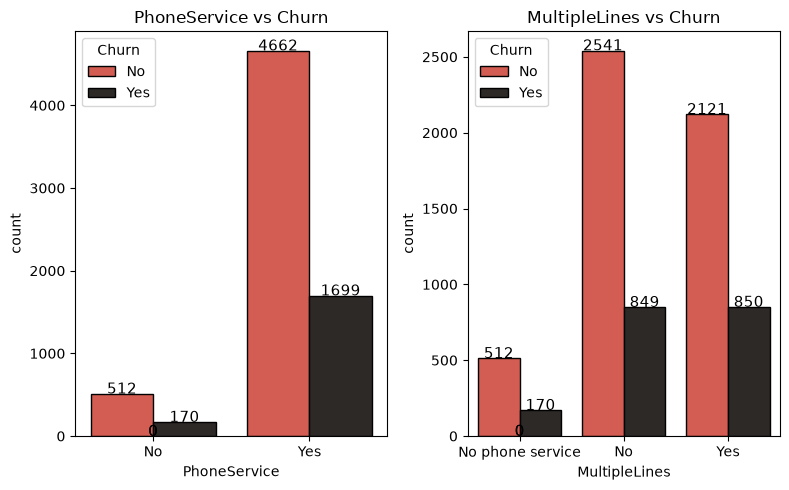

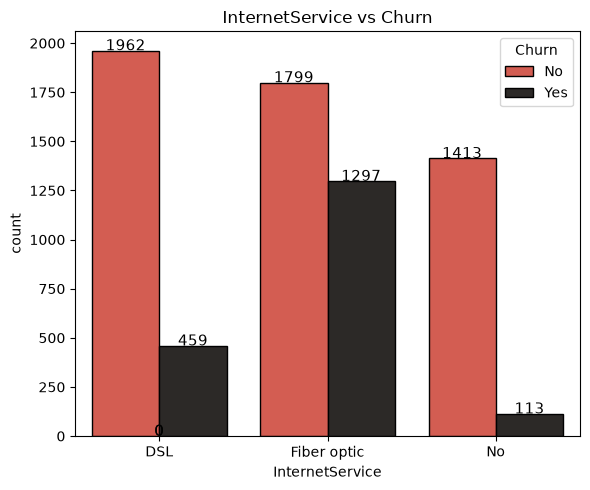

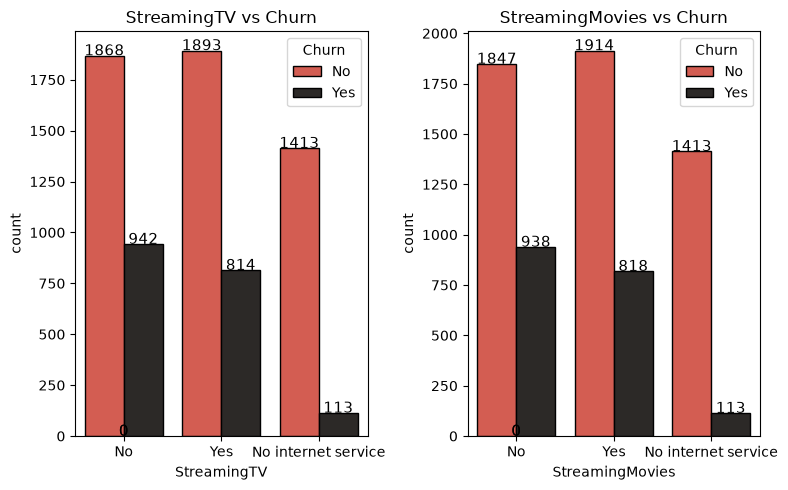

In [19]:
# First 2 features
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))

for i in range(len(l2[0:2])):
    plt.subplot(1, 2, i + 1)

    ax = sns.countplot(
        x=l2[i],
        data=data,
        hue="Churn",
        palette=colors,
        edgecolor='black'
    )

    for rect in ax.patches:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 2,
            int(rect.get_height()),
            ha='center',
            fontsize=11
        )

    plt.title(l2[i] + ' vs Churn')

plt.tight_layout()
plt.show()


# 3rd feature
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

ax = sns.countplot(
    x=l2[2],
    data=data,
    hue="Churn",
    palette=colors,
    edgecolor='black'
)

for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 2,
        int(rect.get_height()),
        ha='center',
        fontsize=11
    )

plt.title(l2[2] + ' vs Churn')

plt.tight_layout()
plt.show()


# 4th and 5th features
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))

for i in range(len(l2[3:5])):
    plt.subplot(1, 2, i + 1)

    ax = sns.countplot(
        x=l2[i + 3],       # CORRECTED
        data=data,
        hue="Churn",
        palette=colors,
        edgecolor='black'
    )

    for rect in ax.patches:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 2,
            int(rect.get_height()),
            ha='center',
            fontsize=11
        )

    plt.title(l2[i + 3] + ' vs Churn')  # CORRECTED

plt.tight_layout()
plt.show()

- **PhoneService Analysis:**
  Notably, a higher retention rate is observed among customers with no phone service compared to those who opted to discontinue the service.

- **MultipleLines Impact:**
  The churn rate appears consistent irrespective of whether customers have subscribed to multiple lines or not.

- **InternetService Preferences:**
  A considerable number of customers exhibit a preference against utilizing Fiber optic cables for InternetService. Conversely, the data suggests a greater inclination towards DSL among customers.

- **Insights on Streaming Services:**
  Both StreamingTV and StreamingMovies exhibit parallel churn patterns. Regardless of subscription status, a noteworthy number of customers have experienced churn. This implies that factors beyond streaming content alone contribute to customer disengagement.

These observations shed light on customer behavior concerning the services they avail, offering valuable insights for devising targeted strategies to enhance customer retention.

### Group 2: Customer-Enlisted Services

This category comprises features related to security and support services subscribed by the customer:

- **OnlineSecurity**
- **OnlineBackup**
- **DeviceProtection**
- **TechSupport**

Exploring these attributes will provide insights into how customers engage with security and support services, guiding the development of strategies to enhance customer satisfaction and retention.

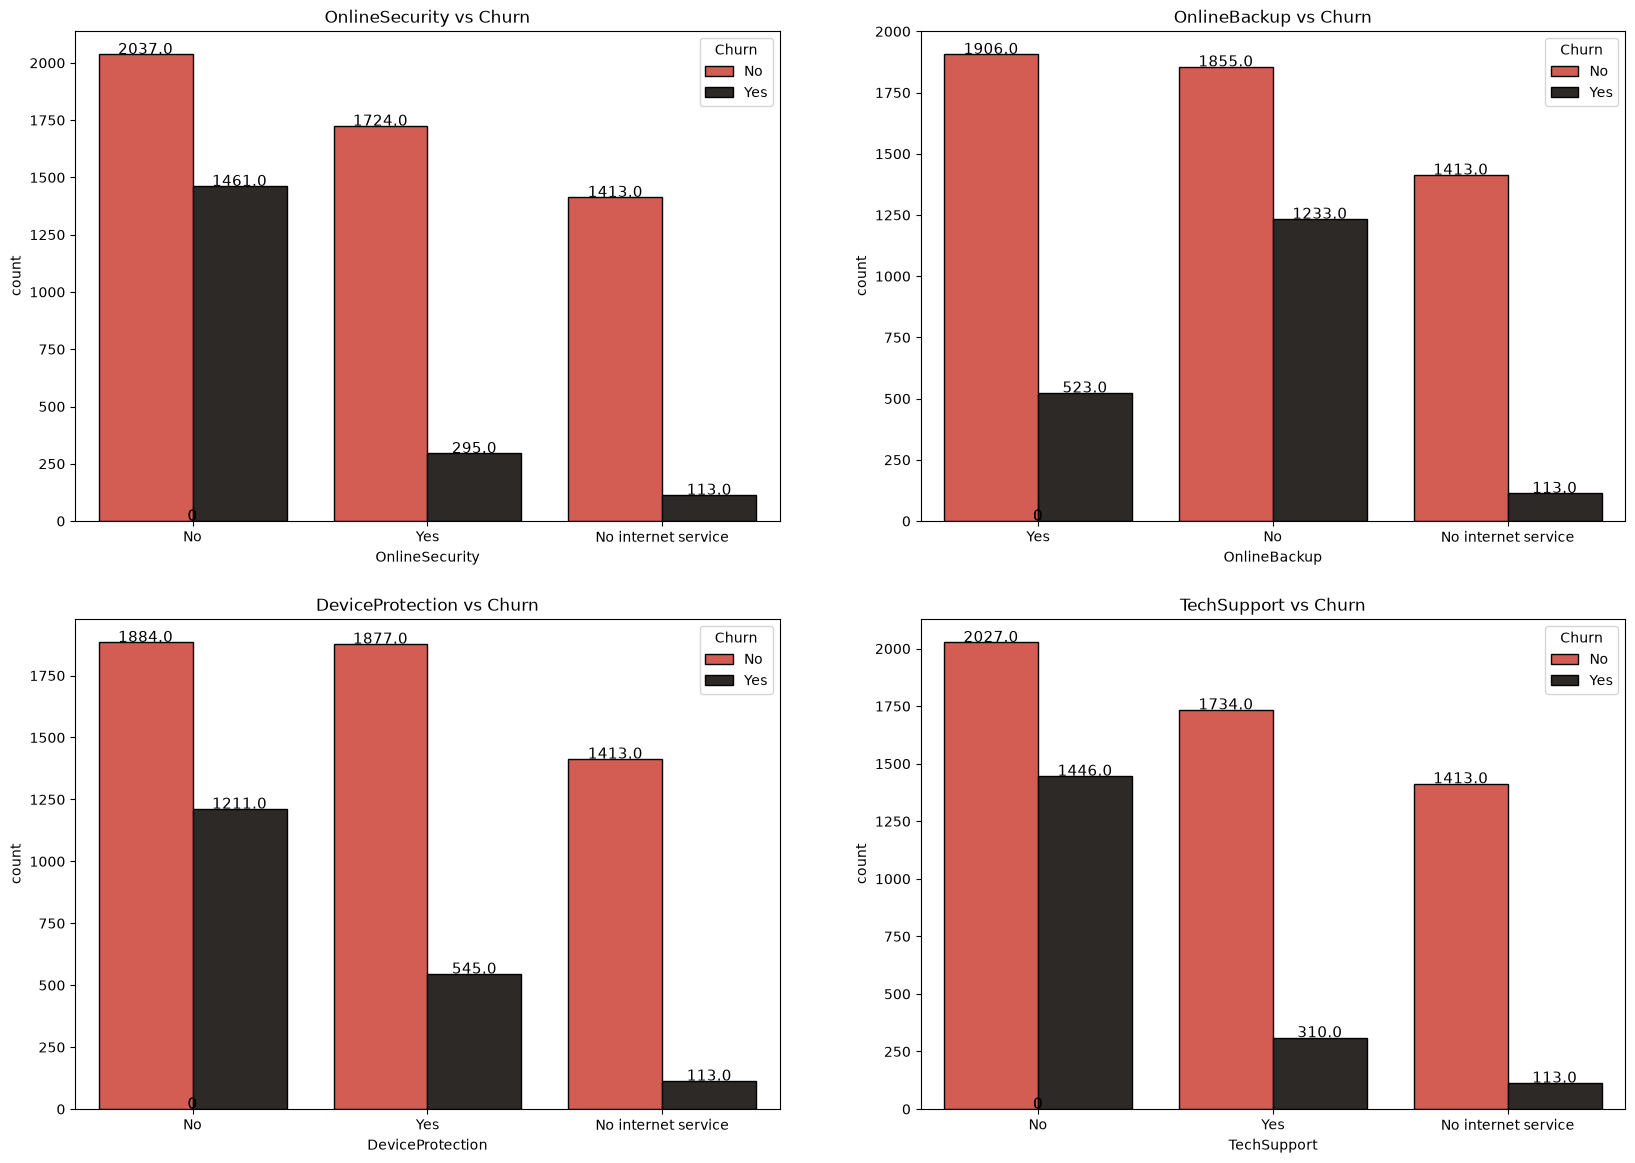

In [20]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.countplot(x=l2[-4 + i],data = data,hue = "Churn",palette = colors,edgecolor = 'black')
    for rect in ax.patches:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
    title = l2[-4 + i] + ' vs Churn'
    plt.title(title);

The visualizations indicate the critical importance of services related to OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport in retaining customers. A notable number of customers have opted to switch service providers, emphasizing the significance of providing robust and satisfactory services in these areas. These findings underscore the need for focused efforts in improving and promoting these services to enhance overall customer satisfaction and retention.

### Group 3

This group encompasses features related to contractual terms, billing preferences, and payment methods:

- **Contract**
- **PaperlessBilling**
- **PaymentMethod**

Analyzing these attributes will provide insights into customer preferences regarding contractual commitments, billing processes, and payment methods, guiding strategies for optimizing customer satisfaction and retention.

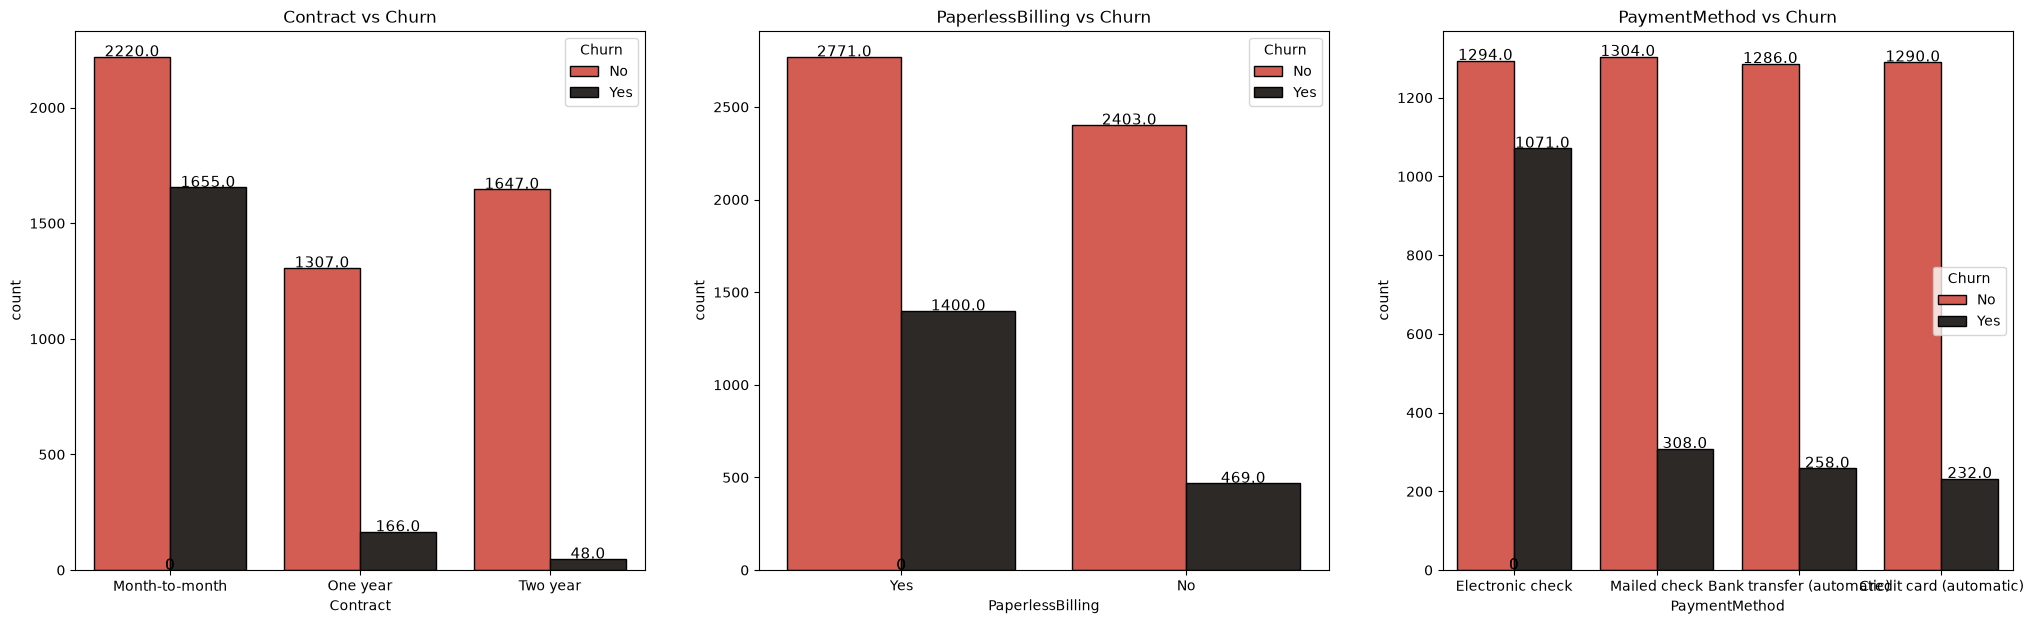

In [21]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))

plt.subplot(1,3,1)
ax = sns.countplot(x=l3[0],data = data,hue = "Churn",palette = colors,edgecolor = 'black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
title = l3[0] + ' vs Churn'
plt.title(title);

plt.subplot(1,3,2)
ax = sns.countplot(x=l3[1],data = data,hue = "Churn",palette = colors,edgecolor = 'black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
title = l3[1] + ' vs Churn'
plt.title(title);

plt.subplot(1,3,3)
ax = sns.countplot(x=l3[2],data = data
                   ,hue = "Churn",palette = colors,edgecolor = 'black')
for rect in ax.patches:
     ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
title = l3[2] + ' vs Churn'
plt.title(title);

- **Contract Analysis:**
  Customer churn is notably high for Month-to-Month contracts. This could be attributed to customers testing various services and opting for shorter-term commitments to explore available options or save costs.

- **PaperlessBilling Impact:**
  A considerable number of customers experience churn in the presence of PaperlessBilling, suggesting potential issues related to payment or receipt processes.

- **PaymentMethod Insights:**
  Customers exhibit a strong aversion to the Electronic check payment method. Of the 2365 bills paid using Electronic check, a significant 1071 customers chose to discontinue services. Addressing issues with Electronic check or reconsidering its inclusion may be necessary for improved customer satisfaction.

These observations underscore the importance of understanding customer preferences in contractual terms, billing methods, and payment processes. Implementing measures to address specific pain points can contribute significantly to customer retention efforts.

### Analysis of Categorical Features in Relation to Churn Cases

This investigation centers on examining the impact of categorical features specifically concerning customers who have experienced churn. The goal is to discern patterns, correlations, and influential factors among these categorical features within the context of churn cases. The findings from this analysis will provide valuable insights for optimizing strategies aimed at customer retention.


### Group 1: Customer Information

In this grouping, we explore the relationship between customer information and churn cases, focusing on the following categorical features:

- **Gender**
- **SeniorCitizen**
- **Partner**
- **Dependents**

This analysis aims to uncover patterns and associations within these specific customer attributes concerning instances of customer churn.

In [22]:
gender = data[data['Churn'] == 'Yes']['gender'].value_counts()
gender = [
    gender.iloc[0] / sum(gender) * 100,
    gender.iloc[1] / sum(gender) * 100
]  # Female / Male

seniorcitizen = data[data['Churn'] == 'Yes']['SeniorCitizen'].value_counts()
seniorcitizen = [
    seniorcitizen.iloc[0] / sum(seniorcitizen) * 100,
    seniorcitizen.iloc[1] / sum(seniorcitizen) * 100
]  # No - Yes

partner = data[data['Churn'] == 'Yes']['Partner'].value_counts()
partner = [
    partner.iloc[0] / sum(partner) * 100,
    partner.iloc[1] / sum(partner) * 100
]  # No - Yes

dependents = data[data['Churn'] == 'Yes']['Dependents'].value_counts()
dependents = [
    dependents.iloc[0] / sum(dependents) * 100,
    dependents.iloc[1] / sum(dependents) * 100
]  # No - Yes

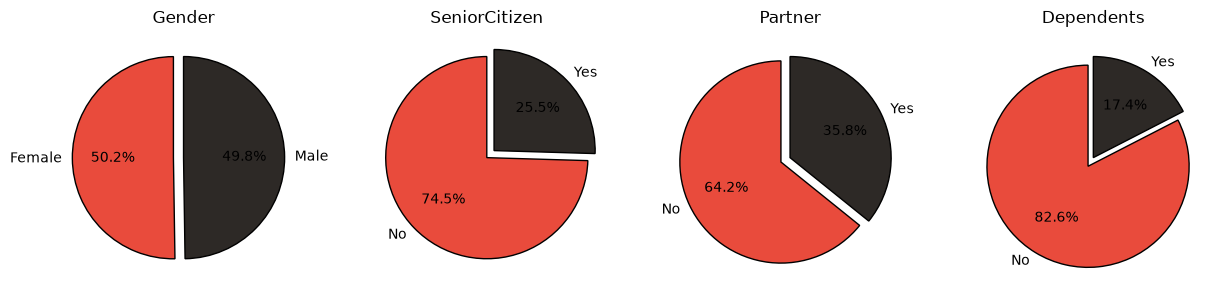

In [23]:
ax,fig = plt.subplots(nrows = 1,ncols = 4,figsize = (15,15))

plt.subplot(1,4,1)
plt.pie(gender,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender');

plt.subplot(1,4,2)
plt.pie(seniorcitizen,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('SeniorCitizen');

plt.subplot(1,4,3)
plt.pie(partner,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Partner');

plt.subplot(1,4,4)
plt.pie(dependents,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Dependents');

- **Gender Analysis:**
  A distinct 50% - 50% split is observed between male and female customers who have switched services. This suggests that the reasons for switching are likely related to service quality or specific processes that elicited negative reactions from customers.

- **SeniorCitizen Impact:**
  A substantial 75% of churned customers are not classified as SeniorCitizens. This highlights a critical area where the company should focus its attention for customer retention strategies.

- **Living Arrangements Influence:**
  Customers living independently, without partners or dependents, have prominently discontinued services. The data indicates that, on average, 73.4% of customers who churned were living independently.

These insights provide a targeted understanding of how specific customer information attributes relate to instances of churn. Addressing these aspects can contribute significantly to the development of effective customer retention initiatives.

### Group 2: Customer-Enlisted Services

In this grouping, we investigate the relationship between services subscribed by the customer and instances of churn. The focus is on the following categorical features:

- **PhoneService**
- **MultipleLines**
- **InternetService**
- **StreamingTV**
- **StreamingMovies**

This analysis aims to uncover patterns and correlations within these specific service-related attributes concerning cases of customer churn.

In [24]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [25]:
# PhoneService: No - Yes
phoneservice = (
    data[data['Churn'] == 'Yes']['PhoneService']
    .value_counts(normalize=True)
    .reindex(['No', 'Yes'], fill_value=0)
    * 100
)

# MultipleLines: No - No phone service - Yes
multiplelines = (
    data[data['Churn'] == 'Yes']['MultipleLines']
    .value_counts(normalize=True)
    .reindex(['No', 'No phone service', 'Yes'], fill_value=0)
    * 100
)

# InternetService: DSL - Fiber optic - No
internetservice = (
    data[data['Churn'] == 'Yes']['InternetService']
    .value_counts(normalize=True)
    .reindex(['DSL', 'Fiber optic', 'No'], fill_value=0)
    * 100
)

# StreamingTV: No - No internet service - Yes
streamingtv = (
    data[data['Churn'] == 'Yes']['StreamingTV']
    .value_counts(normalize=True)
    .reindex(['No', 'No internet service', 'Yes'], fill_value=0)
    * 100
)

# StreamingMovies: No - No internet service - Yes
streamingmovies = (
    data[data['Churn'] == 'Yes']['StreamingMovies']
    .value_counts(normalize=True)
    .reindex(['No', 'No internet service', 'Yes'], fill_value=0)
    * 100
)

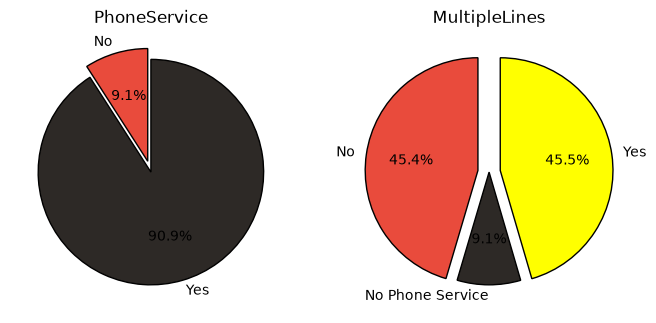

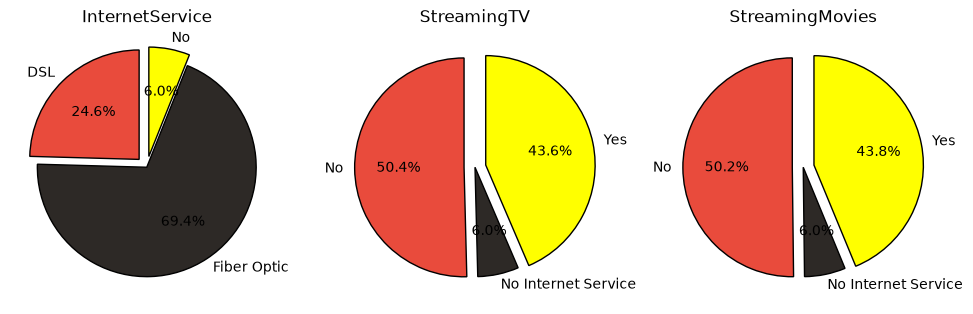

In [26]:
colors = ['#2E86AB', '#E63946', '#A8DADC']  # teal blue / coral red / light teal
ax,fig = plt.subplots(nrows = 1,ncols = 2,figsize = (8,8))

plt.subplot(1,2,1)
plt.pie(phoneservice,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PhoneService');

plt.subplot(1,2,2)
plt.pie(multiplelines,labels = ['No','No Phone Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('MultipleLines');

ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(internetservice,labels = ['DSL', 'Fiber Optic','No'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('InternetService');

plt.subplot(1,3,2)
plt.pie(streamingtv,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingTV');

plt.subplot(1,3,3)
plt.pie(streamingmovies,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingMovies');

- **PhoneService Impact:**
  Despite the provision of PhoneService, a significant percentage of customers switched, suggesting dissatisfaction or other service-related issues.

- **MultipleLines Influence:**
  The availability of MultipleLines did not significantly affect customer unsubscription, indicating its limited impact on churn.

- **InternetService Preferences:**
  A notable 70% of customers opted out from services involving Fiber Optic cables for InternetService, signaling a strong preference against this technology.

- **Streaming Services Insights:**
  While customers without StreamingTV and StreamingMovies services tended to cancel their subscriptions, an average of 43.7% of customers with these services switched. This suggests that other factors beyond streaming content contribute to customer churn.

### Group 3

This grouping delves into the relationship between contract terms, billing preferences, and payment methods selected by the customer, specifically in the context of instances of churn. The categorical features under scrutiny are:

- **Contract**
- **PaperlessBilling**
- **PaymentMethod**

Analyzing these attributes aims to reveal patterns and correlations within these specific contractual and financial service-related features concerning cases of customer churn.

In [27]:
# Contract
contract = (
    data[data['Churn'] == 'Yes']['Contract']
    .value_counts(normalize=True)
    .reindex(['Month-to-month', 'One year', 'Two year'], fill_value=0)
    * 100
)


# Paperless Billing
paperlessbilling = (
    data[data['Churn'] == 'Yes']['PaperlessBilling']
    .value_counts(normalize=True)
    .reindex(['No', 'Yes'], fill_value=0)
    * 100
)


# Payment Method
paymentmethod = (
    data[data['Churn'] == 'Yes']['PaymentMethod']
    .value_counts(normalize=True)
    .reindex([
        'Bank transfer (automatic)',
        'Credit card (automatic)',
        'Electronic check',
        'Mailed check'
    ], fill_value=0)
    * 100
)

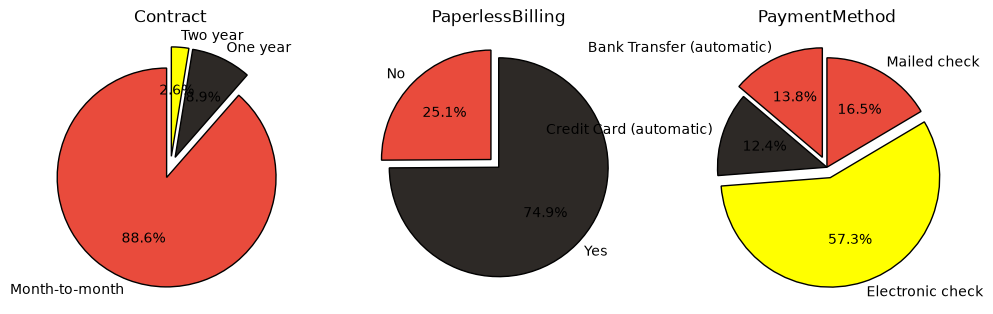

In [28]:
colors = ['#2E86AB', '#E63946', '#A8DADC']  # teal blue / coral red / light teal
ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(contract,labels = ['Month-to-month','One year','Two year'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Contract');

plt.subplot(1,3,2)
plt.pie(paperlessbilling,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaperlessBilling');

plt.subplot(1,3,3)
plt.pie(paymentmethod,labels = ['Bank Transfer (automatic)','Credit Card (automatic)','Electronic check','Mailed check'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaymentMethod');

- **Contract Duration Impact:**
  Monthly contracts dominate customer churn, with a substantial 88.6% share. This highlights the need to explore alternatives or incentives for longer-term commitments.

- **PaperlessBilling Analysis:**
  PaperlessBilling does not garner positive sentiment among customers, evident from the significant churn associated with this billing method.

- **PaymentMethod Insights:**
  Electronic check emerges as a significant concern, contributing to 57.3% of churn. Addressing issues with this payment method is crucial. Mailed check, Bank Transfer (automatic), and Credit Card (automatic) follow, necessitating attention to improve the overall payment experience for customers.

These findings provide actionable insights for refining contract terms, billing preferences, and payment methods to enhance customer satisfaction and retention.

## Numerical Features Distribution
In this analysis, we explore the distribution of numerical features to gain insights into the spread and characteristics of quantitative attributes in the dataset.

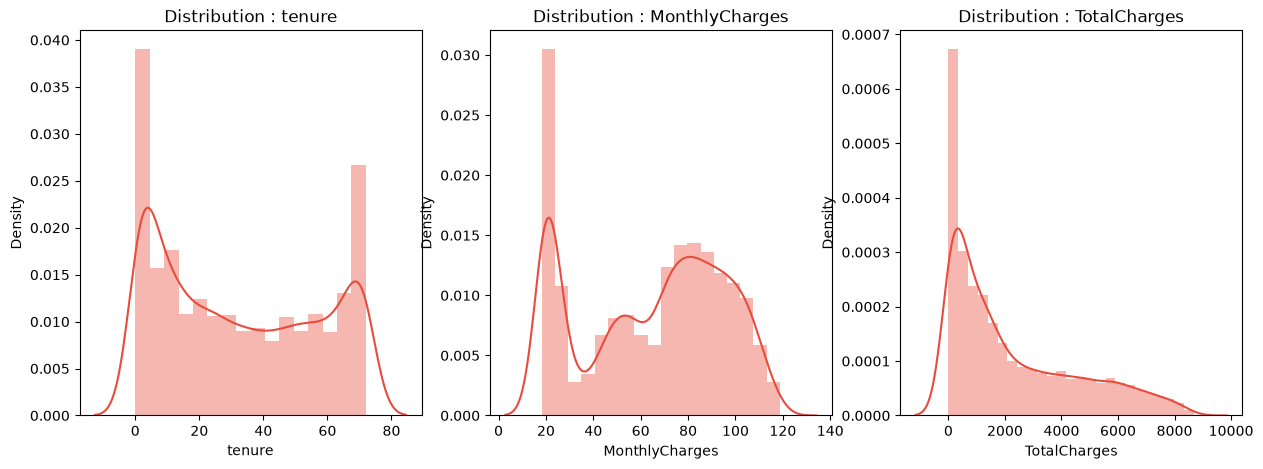

In [29]:
fig, ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(len(numerical_features)):
    plt.subplot(1,3,i+1)
    sns.distplot(data[numerical_features[i]],color = colors[0])
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Tenure Distribution:**
  The tenure distribution exhibits a bimodal pattern with peaks at 0-70, indicating the presence of two distinct groups within the customer base.

- **MonthlyCharges Distribution:**
  MonthlyCharges create a bimodal distribution with peaks at 20-80, suggesting the existence of two prevalent cost structures or service tiers.

- **TotalCharges Distribution:**
  TotalCharges displays a positively or rightly skewed distribution, indicating a concentration of lower values with a gradual tapering towards higher values.

These numerical feature distributions provide valuable insights into the varied patterns within customer tenure, monthly charges, and total charges. Understanding these distributions aids in refining strategies for customer segmentation and engagement.

## Target Variable (Outcome) in Relation to Numerical Features

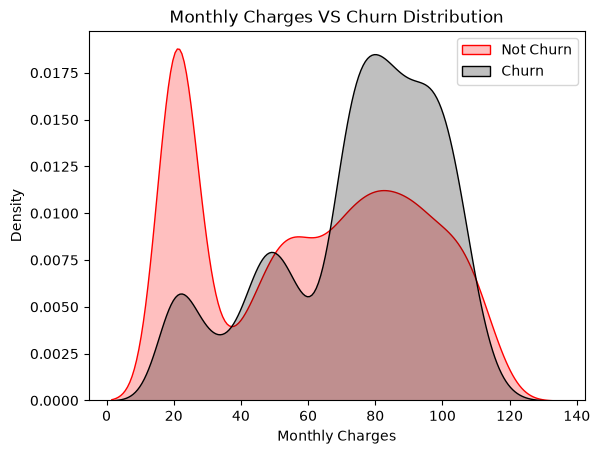

In [30]:
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'Yes') ],
                ax =ax, color="Black", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Monthly Charges VS Churn Distribution');


Customers are more likely to churn due to the presence of high monthly charges.

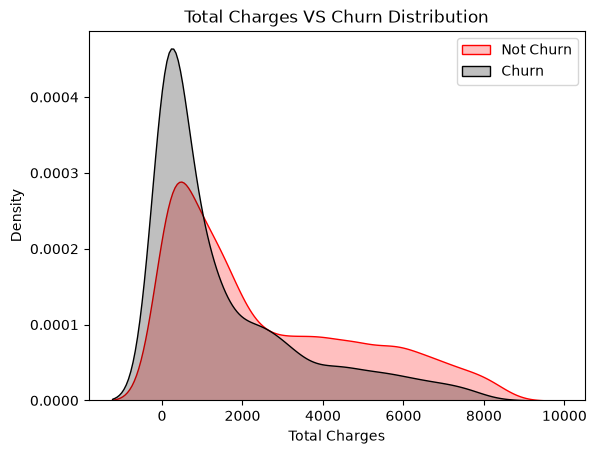

In [31]:
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'No') ],
                color="red", shade = True);
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'Yes') ],
                ax =ax, color="black", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Total Charges VS Churn Distribution');

The observation that high Total Charges are associated with a higher likelihood of customer churn suggests a potential issue with the pricing system. Addressing and optimizing the pricing structure is crucial to mitigate this factor contributing to customer churn. A thorough examination and potential adjustments in pricing strategies may help enhance customer satisfaction and retention.

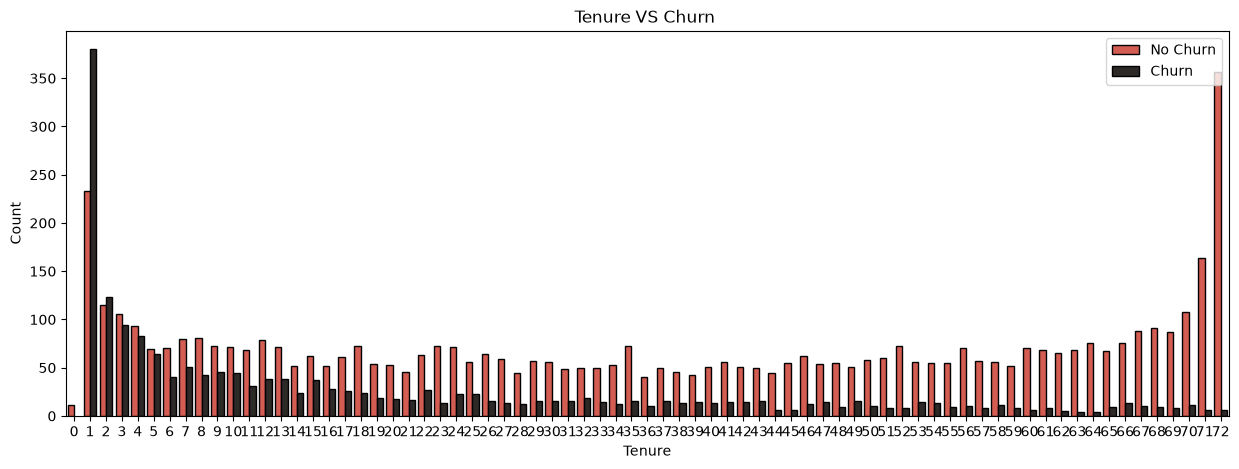

In [32]:
plt.figure(figsize = (15,5))
sns.countplot(x='tenure', data=data, hue='Churn', palette = colors, edgecolor='black')
plt.title('Tenure VS Churn ')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.legend(['No Churn', 'Churn'], loc='upper right')
plt.show()

- **Tenure Analysis:**
  A substantial number of customers exit within the first month, with high cancellations continuing for 4-5 months. However, churn numbers decrease as tenure increases. The graph exhibits a symmetrical pattern, with the left side dominated by high churn numbers and the right side characterized by lower churn numbers. This highlights a correlation between longer customer tenure and reduced likelihood of churn. Understanding and leveraging this trend can inform strategies to enhance customer retention over time.

## Quantitative features vs. Quantitative features with respect to the Target Variable (Churn)

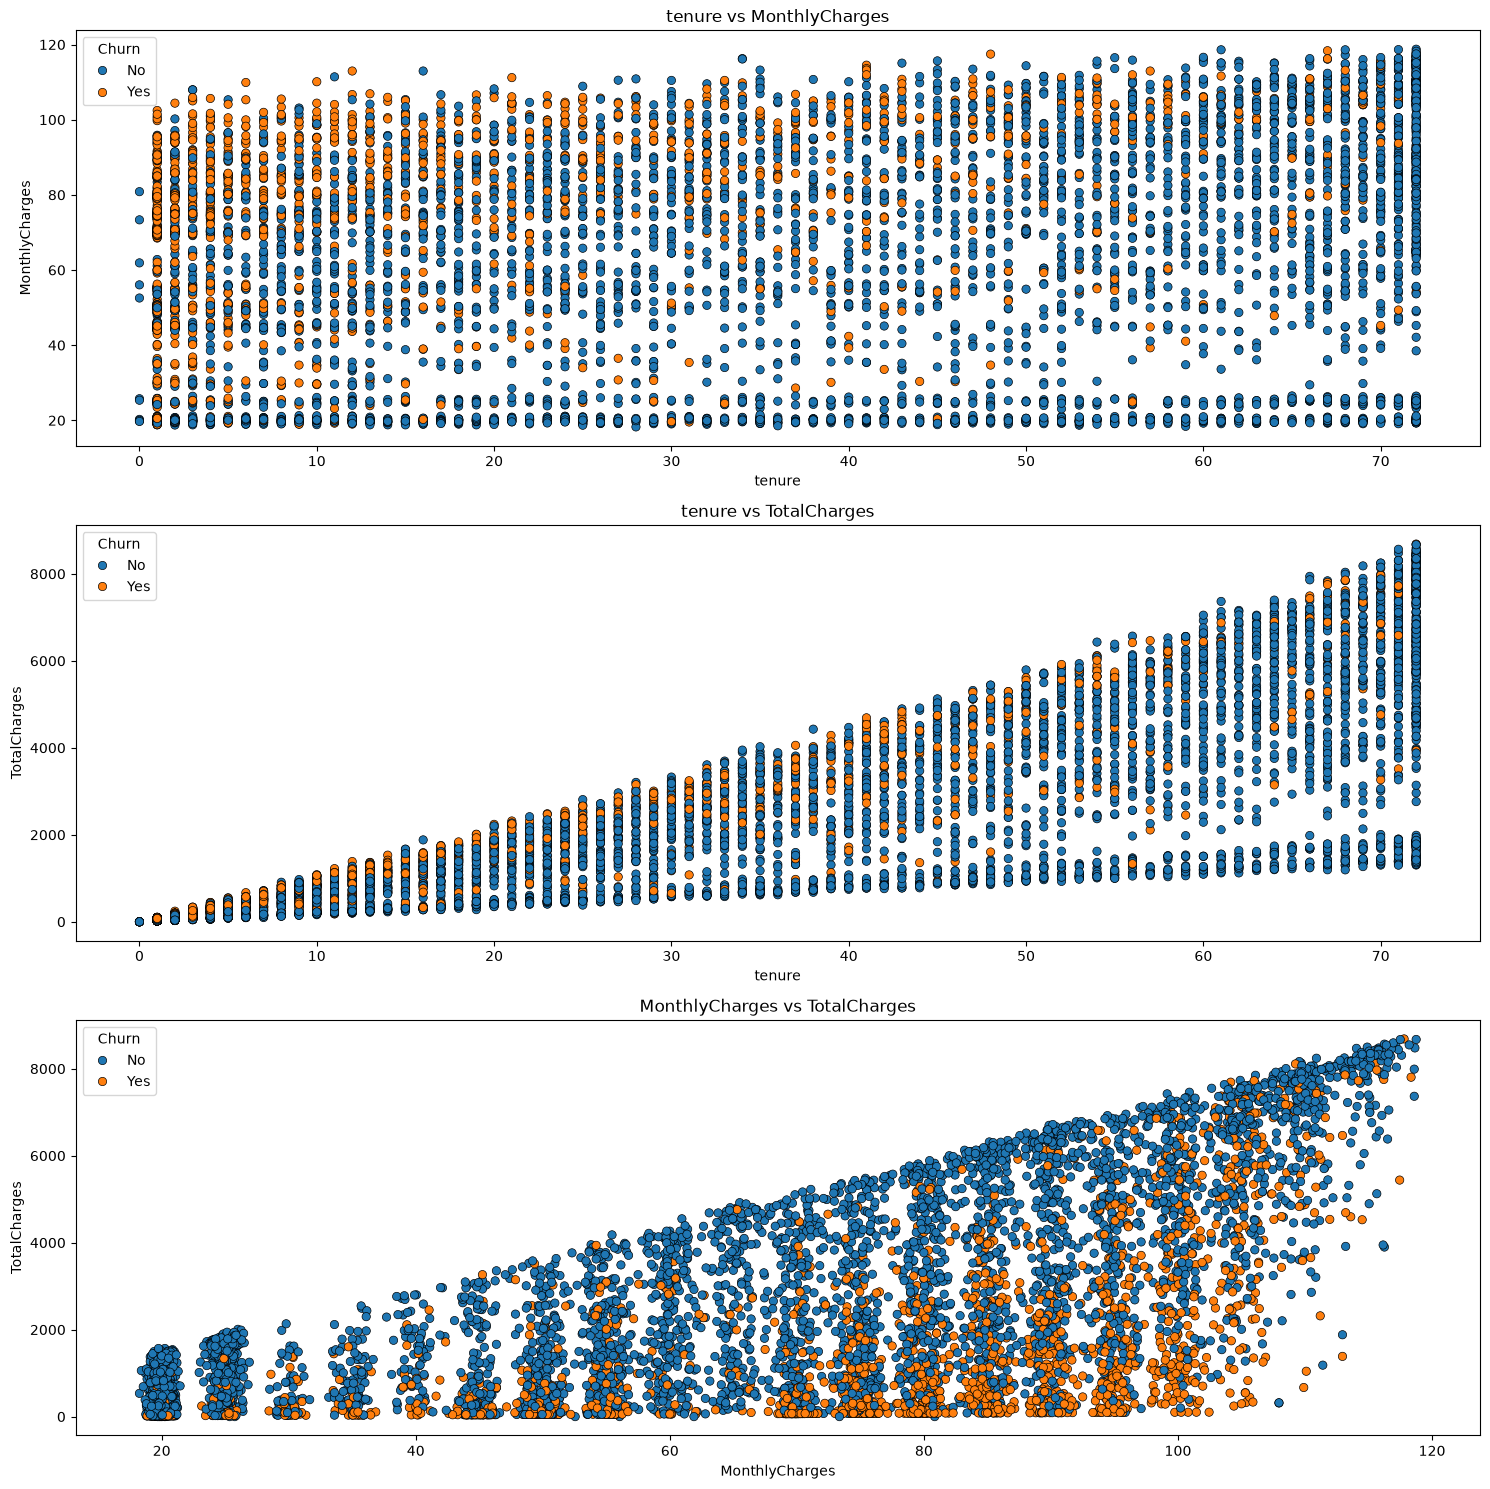

In [33]:
colors = {
    'No': '#2E86AB',    # Teal blue
    'Yes': '#E63946'    # Coral red
}

a = 0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,15))

for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):

        if i != j and j > i:
            a += 1

            plt.subplot(3,1,a)

            sns.scatterplot(
                x=numerical_features[i],
                y=numerical_features[j],
                data=data,
                hue='Churn',
                hue_order=['No', 'Yes'],
                palette=colors,
                edgecolor='black'
            )

            plt.title(
                numerical_features[i] + ' vs ' + numerical_features[j]
            )

            plt.legend(title='Churn', loc='upper left')

plt.tight_layout()
plt.show()

- **Tenure and MonthlyCharges Relationship:**
  - For tenure within the 0-20 months period, customer churn occurs across various MonthlyCharges values.
  - From 20-60 months tenure, customers with higher MonthlyCharges values (70-120) exhibit an increased likelihood of dropping out.

- **TotalCharges vs Tenure:**
  - As tenure increases, TotalCharges also increase, indicating a positive correlation.
  - Customers opting out are typically those charged the highest within their tenure period, along with some in the middle range.

- **MonthlyCharges Threshold:**
  - Customers tend to decide to cancel their subscriptions when MonthlyCharges reach 70 and above.

These insights emphasize the nuanced relationships between tenure, MonthlyCharges, and TotalCharges, providing valuable information for optimizing pricing strategies and customer retention efforts.

# Overview of Exploratory Data Analysis

In customer churn analysis, certain categorical features reveal distinct hierarchies crucial for targeted retention strategies. **Male** customers are more likely to churn than females, while **SeniorCitizens** exhibit lower churn rates. Not having a **partner** or **dependents** increases churn likelihood. Regarding services, having **phone service** and **multiple lines** correlates with lower churn, and **fiber optic** internet users are more prone to churn than DSL users. The absence of online security, online backup, etc., indicates higher churn.

Contract-wise, **month-to-month** contracts show higher churn than one-year and two-year contracts. **PaperlessBilling** customers are more likely to churn. In payment methods, **electronic checks** users have a higher churn risk, followed by mailed checks, bank transfers (automatic), and credit cards (automatic). Understanding these hierarchies is essential for devising effective retention strategies.

## Buisness insights 


### Key Business Insights

**Overall churn health**
1. **Churn rate: 26.5%** (1,869 of 7,043 customers) vs **retention rate: 73.5%** (5,174 customers) — roughly 1 in 4 customers leaves.
2. Churned customers pay **~22% more per month** on average ($74.44) than retained customers ($61.27), yet stay **less than half as long** (17.98 vs 37.57 months tenure) — the business is disproportionately losing its higher-value customers, and losing them early.
3. Churned customers accumulate ~40% lower lifetime value before leaving ($1,531.80 avg TotalCharges) than retained customers go on to generate ($2,555.34 avg) — most of a customer's potential value is lost before the relationship matures.

**Contract, billing & payment — the strongest levers**
4. **Contract length is the single strongest churn driver.** Month-to-month contracts dominate churn with an **88.6% share** of all cancellations, far ahead of one-year and two-year contracts, consistent with tenure's strong negative correlation with churn (**r = -0.35**, the largest of any feature).
5. **Electronic check is a red flag payment method**: of 2,365 customers paying by electronic check, **1,071 churned — a 45.3% churn rate within that group**, and 57.3% of all churn company-wide. Mailed check, bank transfer (automatic), and credit card (automatic) trail far behind.
6. **PaperlessBilling customers churn more** than paper-billing customers, suggesting friction or lower engagement in the digital billing experience itself.

**Services & support — retention anchors, not just upsells**
7. Customers **without OnlineSecurity, OnlineBackup, DeviceProtection, or TechSupport churn substantially more** than those with these services — these should be treated as retention-anchoring add-ons rather than pure revenue upsells.
8. **Fiber optic customers churn more than DSL customers**, despite Fiber being the premium, higher-revenue product — pointing to a service quality, reliability, or price-perception gap specific to Fiber.
9. StreamingTV/StreamingMovies show **no protective effect on their own** — churn happens at similar rates regardless of subscription status, so streaming isn't a strong retention driver by itself.

**Customer profile**
10. Customers **without a partner or dependents churn more** — about 73.4% of churned customers were living independently, making this a clear segment for targeted outreach.
11. **SeniorCitizens** are a smaller share of the base (1,142 of 7,043) but churn at a notably higher within-segment rate: **476 of 1,142 churned (41.7%)** — a high-risk, high-service-expectation segment worth dedicated attention, even though 75% of *all* churned customers are non-seniors.

**Pricing & tenure dynamics**
12. Churn probability rises sharply once **MonthlyCharges cross ~$70/month** — a clear price-sensitivity or value-perception threshold.
13. Churn is **front-loaded**: a large share of cancellations happen in month 1, with elevated churn persisting through months 2–5, then tapering steadily as tenure increases — classic early-lifecycle attrition that a structured onboarding/retention program could target directly.


## KPI Framework for Retention

The six KPIs below turn the insights above into numbers the business can track monthly. All figures are computed from the full 7,043-customer dataset, using **MonthlyCharges** as the recurring-revenue proxy.

| KPI | Formula | Current Value | What it tells you |
|---|---|---|---|
| **Average Revenue Per Customer (ARPU)** | Total Monthly Charges ÷ Total Customers | **$64.76 / month** | Overall pricing / monetization level |
| **Churned Customers by Contract** | Count of churned customers grouped by Contract type | MTM: 1,655 (88.6%) · 1‑yr: 166 (8.9%) · 2‑yr: 48 (2.6%) | Where churn risk concentrates |
| **Churned Revenue (monthly, lost)** | Σ MonthlyCharges of churned customers | **$139,128 / month** (~$1.67M / year) | Revenue actively being lost to churn |
| **Retained Revenue (monthly)** | Σ MonthlyCharges of retained customers | **$317,011 / month** (~$3.80M / year) | Revenue base currently secured |
| **Retention Rate** | Retained Customers ÷ Total Customers | **73.5%** | Share of base successfully kept |
| **Churn Rate** | Churned Customers ÷ Total Customers | **26.5%** | Share of base lost in the period |

### Churn by Contract — Detail

| Contract Type | Total Customers | Churned | Churn Rate | Share of All Churn |
|---|---|---|---|---|
| Month-to-month | 3,875 | 1,655 | 42.7% | 88.6% |
| One year | 1,473 | 166 | 11.3% | 8.9% |
| Two year | 1,695 | 48 | 2.8% | 2.6% |

Month-to-month customers churn **more than 15x** the rate of two-year customers — reinforcing contract length as the biggest single lever available.


## KPI-Linked Retention Recommendations

**Reduce Churn Rate / Raise Retention Rate**
- Migrate month-to-month customers to annual contracts via a structured incentive ladder (e.g. a modest discount or a free add-on service for a 1-year commitment) — the highest-leverage single action given the 42.7% vs 2.8% churn gap.
- Build an early-lifecycle "first 90 days" retention program (proactive check-ins, onboarding support, first-bill review) targeting the front-loaded churn spike in months 1–5.
- Build a churn-risk score (tenure, contract type, payment method, add-on service count) to trigger proactive outreach before cancellation.

**Protect Churned Revenue / Grow Retained Revenue**
- Prioritize save-desk and win-back efforts on high-MonthlyCharges customers on month-to-month contracts — this segment carries the largest revenue-at-risk per customer.
- Bundle OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport into entry-level packages rather than pure upsells — these correlate strongly with retention, not just incremental revenue.
- Audit Fiber optic service quality/pricing perception specifically — losing premium-ARPU customers on the premium product hits both churned revenue and long-term ARPU growth.

**Lift ARPU Sustainably**
- Since churned customers already have higher ARPU than retained customers, raising prices without fixing retention drivers will likely worsen churn — pair any ARPU-growth initiative with the retention actions above.
- Grow ARPU through service attach (security/support bundles, which are retention-positive) rather than base-price increases, especially above the ~$70/month threshold where churn risk rises sharply.

**Fix Payment & Billing Friction**
- Incentivize migration from Electronic check to automatic payment methods (bank transfer/credit card autopay) — e.g. a small statement credit — since electronic check shows a 45.3% within-segment churn rate, far above other methods.
- Review paperless billing communications (clarity, timing, spam-folder risk) to ensure the digital billing experience isn't itself a churn driver.

**Target High-Risk Segments**
- Build a dedicated retention track for SeniorCitizen customers (41.7% within-segment churn rate) with higher-touch support given their apparent higher service expectations.
- Flag customers living independently (no partner, no dependents) for proactive engagement — they make up ~73% of churned customers.

## Suggested Ongoing Tracking Cadence

- Track **Churn Rate** and **Retention Rate** monthly, overall and segmented by Contract type, Payment Method, and Internet Service — the segments where this analysis found the largest gaps.
- Track **Churned Revenue** and **Retained Revenue** monthly in dollar terms (not just customer counts) so finance and retention teams share one number for "revenue at risk."
- Track **ARPU** split by churned vs. retained cohorts each month — a widening gap (churned ARPU pulling further above retained ARPU) is an early warning that the business is losing its best customers.
